# CSRNet - Enhanced Version
## With VGG16-only Model, Time Tracking, and Comprehensive Evaluation

In [20]:
import os
import cv2
import cv2 as cv
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import models, transforms
from scipy.io import loadmat
import matplotlib.pyplot as plt
import time
from datetime import timedelta

In [21]:
def generate_density_map(shape, points, sigma=4):
    H, W = shape
    density = np.zeros((H, W), dtype=np.float32)

    for x, y in points:
        x, y = int(x), int(y)
        if x >= W or y >= H:
            continue
        density[y, x] += 1

    # FIX 1: kernel size must be >= 6*sigma+1 to avoid clipping the Gaussian
    ksize = int(6 * sigma + 1) | 1  # ensure odd; = 25 for sigma=4
    density = cv2.GaussianBlur(density, (ksize, ksize), sigma)
    return density

In [22]:
class TrancosDataset(Dataset):
    def __init__(self, root, downsample_factor=1):
        self.downsample_factor = downsample_factor
        self.img_dir  = os.path.join(root, "images")
        self.dot_dir  = os.path.join(root, "dots")
        self.mask_dir = os.path.join(root, "ground-truth")

        self.images = sorted([f for f in os.listdir(self.img_dir) if f.endswith(".jpg")])

        self.transform = transforms.Compose([
            transforms.ToTensor(),
            transforms.Normalize(
                mean=[0.485, 0.456, 0.406],
                std=[0.229, 0.224, 0.225]
            )
        ])

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img_name = self.images[idx]

        img_path  = os.path.join(self.img_dir,  img_name)
        dot_path  = os.path.join(self.dot_dir,  img_name.replace(".jpg", ".txt"))
        # FIX 2: was missing underscore → produced e.g. "image001mask.mat"
        mask_path = os.path.join(self.mask_dir, img_name.replace(".jpg", "mask.mat"))

        # --- Image ---
        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        img = cv2.resize(
            img,
            (img.shape[1] // self.downsample_factor,
             img.shape[0] // self.downsample_factor)
        )

        # FIX 3: pad H and W to multiples of 8 so model output matches density size
        h, w, _ = img.shape
        h_pad = (8 - h % 8) % 8
        w_pad = (8 - w % 8) % 8
        if h_pad > 0 or w_pad > 0:
            img = cv2.copyMakeBorder(img, 0, h_pad, 0, w_pad, cv2.BORDER_REFLECT)
        h, w = img.shape[:2]

        # --- Points ---
        dot_path = os.path.join(self.dot_dir, img_name.replace(".jpg", "dots.png"))
        dot_img = cv2.imread(dot_path, cv2.IMREAD_COLOR)  # read as BGR
        if dot_img is not None:
            # red dots: high R, low G, low B (in BGR: high B index=2... no, BGR so R=channel 2)
            r = dot_img[:, :, 2]  # red channel in BGR
            g = dot_img[:, :, 1]
            b = dot_img[:, :, 0]
            red_mask = (r > 100) & (g < 50) & (b < 50)
            ys, xs = np.where(red_mask)
            xs = xs / self.downsample_factor
            ys = ys / self.downsample_factor
            points = np.stack([xs, ys], axis=1).astype(np.float32) if len(xs) > 0 else np.zeros((0, 2), dtype=np.float32)
        else:
            points = np.zeros((0, 2), dtype=np.float32)

        # --- Mask ---
        mat  = loadmat(mask_path)
        mask = mat["BW"]
        mask = cv2.resize(mask.astype(np.float32), (w, h))
        mask = (mask > 0).astype(np.float32)

        # FIX 4: cast back to uint8 BEFORE transform; float64 breaks ToTensor scaling
        img = (img * mask[:, :, None]).astype(np.uint8)

        # --- Density map ---
        density = generate_density_map((h, w), points)
        density = cv2.resize(density, (w // 8, h // 8))

        if density.sum() > 0:
            density *= (len(points) / density.sum())

        density *= 100.0

        img     = self.transform(img)
        density = torch.from_numpy(density).unsqueeze(0)

        return img, density

## Model Architectures

In [23]:
class CSRNet(nn.Module):
    """Original CSRNet with VGG16 frontend + dilated convolution backend"""
    def __init__(self):
        super().__init__()
        vgg = models.vgg16(weights=models.VGG16_Weights.DEFAULT).features
        self.frontend = nn.Sequential(*list(vgg.children())[:23])

        self.backend = nn.Sequential(
            nn.Conv2d(512, 512, 3, padding=2, dilation=2), nn.ReLU(),
            nn.Conv2d(512, 512, 3, padding=2, dilation=2), nn.ReLU(),
            nn.Conv2d(512, 512, 3, padding=2, dilation=2), nn.ReLU(),
            nn.Conv2d(512, 256, 3, padding=2, dilation=2), nn.ReLU(),
            nn.Conv2d(256, 128, 3, padding=2, dilation=2), nn.ReLU(),
            nn.Conv2d(128,  64, 3, padding=2, dilation=2), nn.ReLU()
        )

        self.output = nn.Conv2d(64, 1, 1)

    def forward(self, x):
        x = self.frontend(x)
        x = self.backend(x)
        return self.output(x)


class VGG16Only(nn.Module):
    """VGG16-only model (no dilated convolution backend)"""
    def __init__(self,layers=23):
        super().__init__()
        self.layers = layers
        vgg = models.vgg16(weights=models.VGG16_Weights.DEFAULT).features
        self.frontend = nn.Sequential(*list(vgg.children())[:self.layers])
        
        # Direct output from VGG16 features (512 channels)
        self.output = nn.Conv2d(512, 1, 1)

    def forward(self, x):
        x = self.frontend(x)
        return self.output(x)

## Data Loading

In [24]:
DATA_ROOT = "TRANCOS - edited"

downsample_factor = 1  # adjust for memory constraints

train_ds = TrancosDataset(os.path.join(DATA_ROOT, "train_data"), downsample_factor=downsample_factor)
test_ds  = TrancosDataset(os.path.join(DATA_ROOT, "test_data"),  downsample_factor=downsample_factor)

train_loader = DataLoader(train_ds, batch_size=8, shuffle=True, num_workers=0, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=1, shuffle=False, num_workers=0, pin_memory=True)

print("Train:", len(train_ds), "\nTest:", len(test_ds))

Train: 1031 
Test: 213


In [25]:
from torch.amp import autocast, GradScaler
scaler = GradScaler()

## Training Function with Time Tracking

In [26]:
def train_model(model, model_name, epochs=50, save_path=None):
    """
    Train a model with comprehensive time tracking
    
    Args:
        model: The model to train
        model_name: Name for display purposes
        epochs: Number of training epochs
        save_path: Path to save the trained model
    
    Returns:
        Dictionary with training losses and timing information
    """
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = model.to(device)
    
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', factor=0.5, patience=10
    )
    criterion = nn.MSELoss()
    
    train_losses = []
    epoch_times = []
    
    # Freeze frontend initially
    for param in model.frontend.parameters():
        param.requires_grad = False
    
    print(f"\n{'='*60}")
    print(f"Training {model_name}")
    print(f"{'='*60}")
    
    # Start overall training timer
    training_start_time = time.time()
    
    for epoch in range(epochs):
        epoch_start_time = time.time()
        
        model.train()
        total_loss = 0
        
        # Unfreeze frontend after epoch 10
        if epoch == 10:
            print("\n🔓 Unfreezing VGG16 frontend layers...\n")
            for param in model.frontend.parameters():
                param.requires_grad = True

        for i, (img, density) in enumerate(train_loader):
            img     = img.to(device)
            density = density.to(device)

            with autocast('cuda'):
                pred = model(img)
                loss = criterion(pred, density)

            optimizer.zero_grad()
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()

            total_loss += loss.item()

            if i % 75 == 0:
                print(f"Epoch {epoch+1}/{epochs} | Batch {i}/{len(train_loader)} | Loss: {loss.item():.4f}")

        avg_loss = total_loss / len(train_loader)
        train_losses.append(avg_loss)
        scheduler.step(avg_loss)
        
        # Track epoch time
        epoch_time = time.time() - epoch_start_time
        epoch_times.append(epoch_time)
        
        print(f"Epoch {epoch+1} done | Avg Loss: {avg_loss:.4f} | Time: {epoch_time:.2f}s\n")
    
    # Calculate total training time
    total_training_time = time.time() - training_start_time
    
    print(f"\n{'='*60}")
    print(f"Training Complete!")
    print(f"Total Training Time: {str(timedelta(seconds=int(total_training_time)))}")
    print(f"Average Epoch Time: {np.mean(epoch_times):.2f}s")
    print(f"{'='*60}\n")
    
    # Save model if path provided
    if save_path:
        torch.save(model.state_dict(), save_path)
        print(f"Model saved to {save_path}")
    
    return {
        'train_losses': train_losses,
        'epoch_times': epoch_times,
        'total_time': total_training_time,
        'avg_epoch_time': np.mean(epoch_times)
    }

## Train Original CSRNet Model

In [28]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

csrnet_model = CSRNet().to(device)
print(device)
csrnet_results = train_model(
    csrnet_model, 
    "CSRNet (VGG16 + Dilated Convolutions)",
    epochs=45,
    save_path="csrnet_trancos.pth"
)

cuda

Training CSRNet (VGG16 + Dilated Convolutions)
Epoch 1/45 | Batch 0/129 | Loss: 30.6950
Epoch 1/45 | Batch 75/129 | Loss: 18.5309
Epoch 1 done | Avg Loss: 21.9549 | Time: 96.89s

Epoch 2/45 | Batch 0/129 | Loss: 21.4036
Epoch 2/45 | Batch 75/129 | Loss: 21.1894
Epoch 2 done | Avg Loss: 15.9745 | Time: 119.10s

Epoch 3/45 | Batch 0/129 | Loss: 14.2228
Epoch 3/45 | Batch 75/129 | Loss: 11.8975
Epoch 3 done | Avg Loss: 13.1760 | Time: 122.74s

Epoch 4/45 | Batch 0/129 | Loss: 11.2152
Epoch 4/45 | Batch 75/129 | Loss: 11.8092
Epoch 4 done | Avg Loss: 12.0029 | Time: 126.82s

Epoch 5/45 | Batch 0/129 | Loss: 10.8731
Epoch 5/45 | Batch 75/129 | Loss: 9.0888
Epoch 5 done | Avg Loss: 10.8758 | Time: 128.04s

Epoch 6/45 | Batch 0/129 | Loss: 11.7853
Epoch 6/45 | Batch 75/129 | Loss: 9.7471
Epoch 6 done | Avg Loss: 9.4003 | Time: 127.82s

Epoch 7/45 | Batch 0/129 | Loss: 8.7932
Epoch 7/45 | Batch 75/129 | Loss: 6.4841
Epoch 7 done | Avg Loss: 7.2490 | Time: 131.83s

Epoch 8/45 | Batch 0/12

## Train VGG16-Only Model

In [32]:
vgg16_model = VGG16Only().to(device)
print(device)
vgg16_results = train_model(
    vgg16_model,
    "VGG16-Only (No Backend)",
    epochs=45,
    save_path="vgg16only_trancos.pth"
)

cuda

Training VGG16-Only (No Backend)
Epoch 1/45 | Batch 0/129 | Loss: 31.1633
Epoch 1/45 | Batch 75/129 | Loss: 20.8248
Epoch 1 done | Avg Loss: 26.5427 | Time: 29.37s

Epoch 2/45 | Batch 0/129 | Loss: 34.2325
Epoch 2/45 | Batch 75/129 | Loss: 16.7112
Epoch 2 done | Avg Loss: 24.5546 | Time: 36.32s

Epoch 3/45 | Batch 0/129 | Loss: 24.5145
Epoch 3/45 | Batch 75/129 | Loss: 18.4668
Epoch 3 done | Avg Loss: 23.3083 | Time: 40.47s

Epoch 4/45 | Batch 0/129 | Loss: 18.5014
Epoch 4/45 | Batch 75/129 | Loss: 30.1292
Epoch 4 done | Avg Loss: 22.4113 | Time: 38.75s

Epoch 5/45 | Batch 0/129 | Loss: 21.2716
Epoch 5/45 | Batch 75/129 | Loss: 18.7956
Epoch 5 done | Avg Loss: 21.7441 | Time: 45.71s

Epoch 6/45 | Batch 0/129 | Loss: 19.5273
Epoch 6/45 | Batch 75/129 | Loss: 18.3561
Epoch 6 done | Avg Loss: 21.2399 | Time: 48.25s

Epoch 7/45 | Batch 0/129 | Loss: 28.8450
Epoch 7/45 | Batch 75/129 | Loss: 14.3010
Epoch 7 done | Avg Loss: 20.8509 | Time: 48.42s

Epoch 8/45 | Batch 0/129 | Loss: 18.7

## Training Comparison Visualization

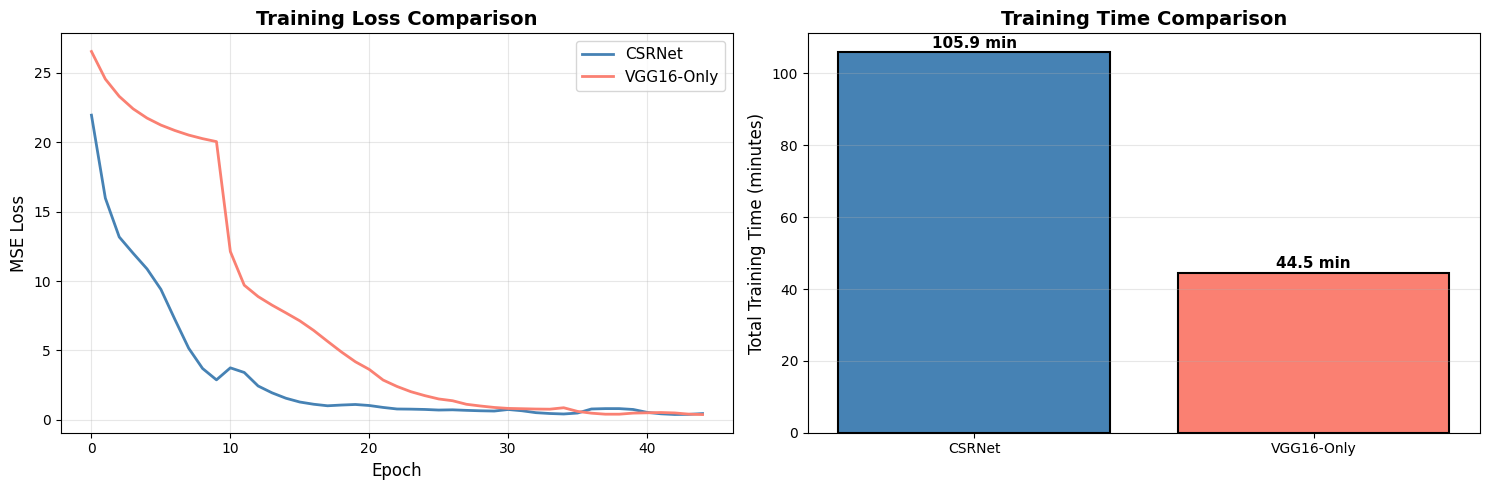


📊 Training comparison saved as 'training_comparison.png'


In [33]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Loss comparison
axes[0].plot(csrnet_results['train_losses'], label='CSRNet', linewidth=2, color='steelblue')
axes[0].plot(vgg16_results['train_losses'], label='VGG16-Only', linewidth=2, color='salmon')
axes[0].set_xlabel('Epoch', fontsize=12)
axes[0].set_ylabel('MSE Loss', fontsize=12)
axes[0].set_title('Training Loss Comparison', fontsize=14, fontweight='bold')
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.3)

# Time comparison
models = ['CSRNet', 'VGG16-Only']
times = [csrnet_results['total_time']/60, vgg16_results['total_time']/60]  # Convert to minutes
colors = ['steelblue', 'salmon']
bars = axes[1].bar(models, times, color=colors, edgecolor='black', linewidth=1.5)
for bar, time_val in zip(bars, times):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                f'{time_val:.1f} min', ha='center', va='bottom', fontsize=11, fontweight='bold')
axes[1].set_ylabel('Total Training Time (minutes)', fontsize=12)
axes[1].set_title('Training Time Comparison', fontsize=14, fontweight='bold')
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('training_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n📊 Training comparison saved as 'training_comparison.png'")

## Evaluation Function with Comprehensive Metrics

In [34]:
def evaluate_model(model, model_name, test_loader, device):
    """
    Evaluate model and compute comprehensive metrics
    
    Returns:
        Dictionary with evaluation metrics and predictions
    """
    print(f"\n{'='*60}")
    print(f"Evaluating {model_name}")
    print(f"{'='*60}\n")
    
    model.eval()
    gt_counts = []
    pred_counts = []
    
    eval_start_time = time.time()
    
    with torch.no_grad():
        for img, density in test_loader:
            img = img.to(device)
            pred = model(img)
            pred_counts.append(pred.sum().item() / 100.0)
            gt_counts.append(density.sum().item() / 100.0)
    
    eval_time = time.time() - eval_start_time
    
    gt_counts   = np.array(gt_counts)
    pred_counts = np.array(pred_counts)

    # Calculate metrics
    mae  = np.mean(np.abs(pred_counts - gt_counts))
    mse  = np.mean((pred_counts - gt_counts) ** 2)
    rmse = np.sqrt(mse)
    mape = np.mean(np.abs((pred_counts - gt_counts) / (gt_counts + 1e-6))) * 100
    r2   = 1 - np.sum((pred_counts - gt_counts) ** 2) / np.sum((gt_counts - gt_counts.mean()) ** 2)
    
    # Additional metrics
    max_error = np.max(np.abs(pred_counts - gt_counts))
    median_ae = np.median(np.abs(pred_counts - gt_counts))
    
    print(f"Evaluation Time: {eval_time:.2f}s")
    print(f"\nMetrics:")
    print(f"  MAE  (Mean Absolute Error):     {mae:.2f} vehicles")
    print(f"  Median AE:                      {median_ae:.2f} vehicles")
    print(f"  RMSE (Root Mean Sq. Error):     {rmse:.2f} vehicles")
    print(f"  MAPE (Mean % Error):            {mape:.2f}%")
    print(f"  R²   (Coefficient of Determination): {r2:.4f}")
    print(f"  Max Error:                      {max_error:.2f} vehicles")
    print(f"{'='*60}\n")
    
    return {
        'gt_counts': gt_counts,
        'pred_counts': pred_counts,
        'mae': mae,
        'mse': mse,
        'rmse': rmse,
        'mape': mape,
        'r2': r2,
        'max_error': max_error,
        'median_ae': median_ae,
        'eval_time': eval_time
    }

## Evaluate Both Models

In [35]:
# Load and evaluate CSRNet
csrnet_model.load_state_dict(torch.load("csrnet_trancos.pth", weights_only=True))
csrnet_eval = evaluate_model(csrnet_model, "CSRNet", test_loader, device)

# Load and evaluate VGG16-Only
vgg16_model.load_state_dict(torch.load("vgg16only_trancos.pth", weights_only=True))
vgg16_eval = evaluate_model(vgg16_model, "VGG16-Only", test_loader, device)


Evaluating CSRNet

Evaluation Time: 14.39s

Metrics:
  MAE  (Mean Absolute Error):     10.53 vehicles
  Median AE:                      9.13 vehicles
  RMSE (Root Mean Sq. Error):     12.05 vehicles
  MAPE (Mean % Error):            29.66%
  R²   (Coefficient of Determination): 0.1790
  Max Error:                      32.11 vehicles


Evaluating VGG16-Only

Evaluation Time: 7.39s

Metrics:
  MAE  (Mean Absolute Error):     3.68 vehicles
  Median AE:                      3.09 vehicles
  RMSE (Root Mean Sq. Error):     4.78 vehicles
  MAPE (Mean % Error):            10.42%
  R²   (Coefficient of Determination): 0.8706
  Max Error:                      15.78 vehicles



## Comprehensive Evaluation Visualization

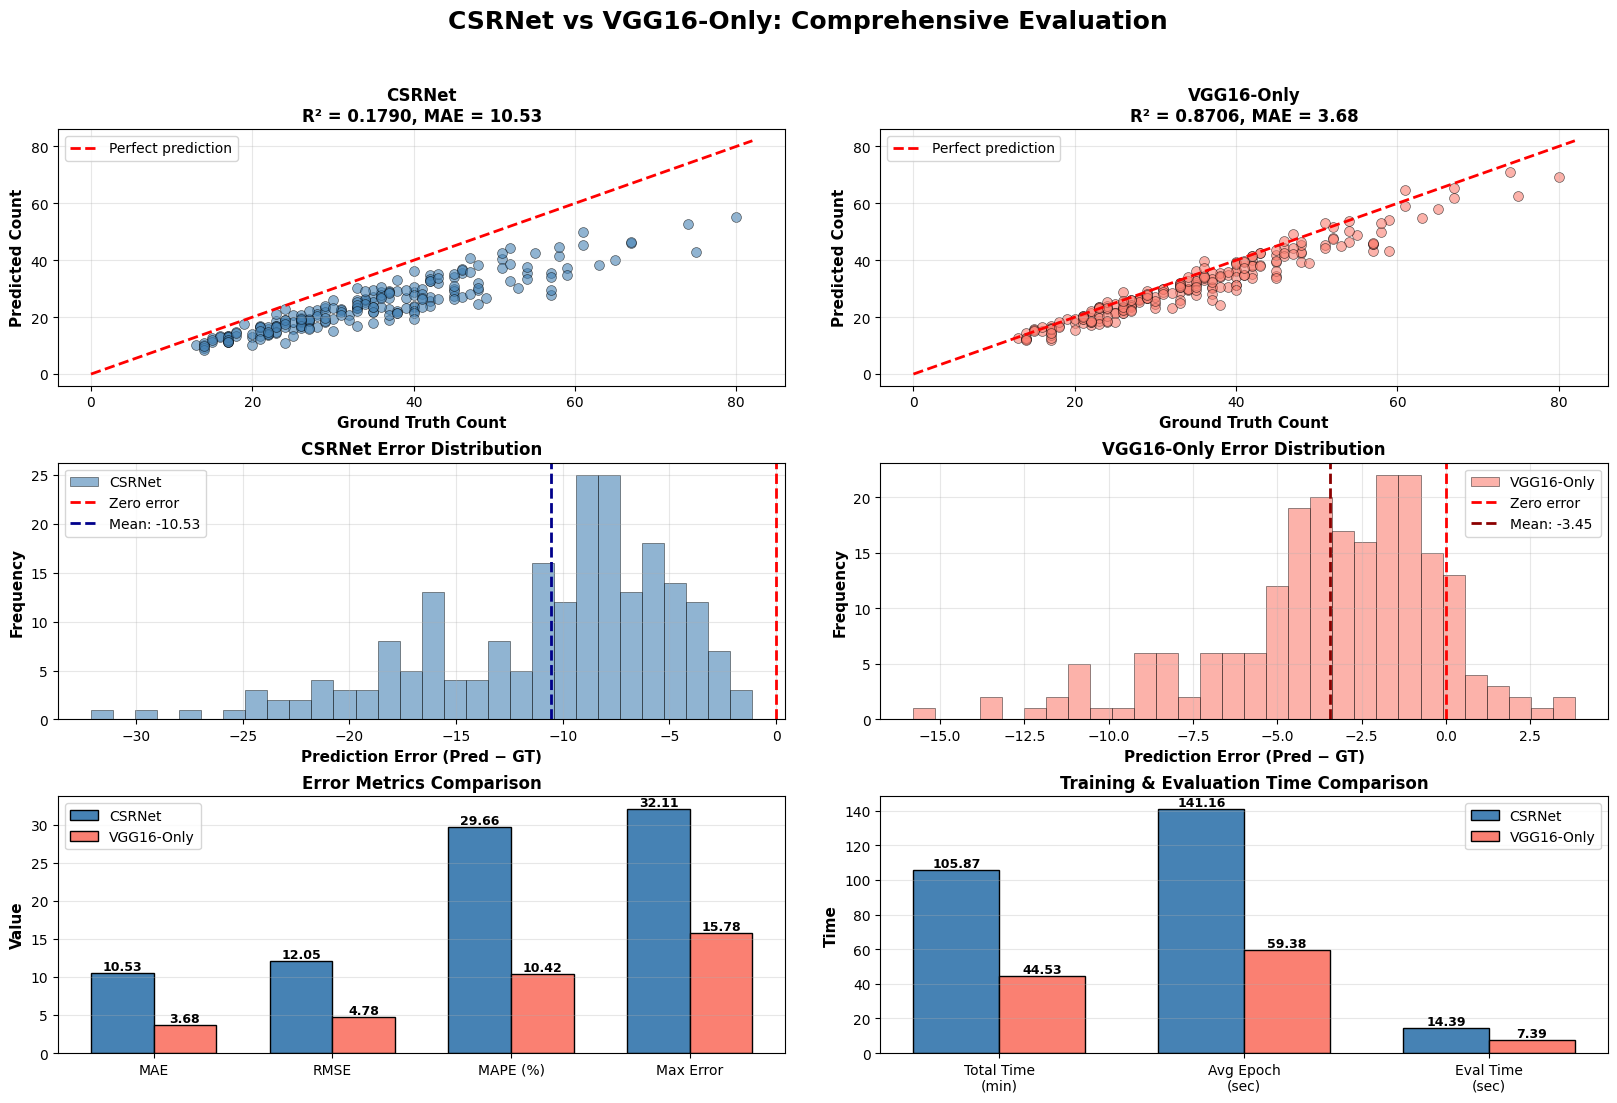


📊 Comprehensive evaluation saved as 'comprehensive_evaluation.png'


In [36]:
fig = plt.figure(figsize=(20, 12))
gs = fig.add_gridspec(3, 4, hspace=0.3, wspace=0.3)

# Title
fig.suptitle('CSRNet vs VGG16-Only: Comprehensive Evaluation', 
             fontsize=18, fontweight='bold', y=0.98)

# ============ ROW 1: Scatter plots ============
for idx, (eval_results, name, color) in enumerate([
    (csrnet_eval, 'CSRNet', 'steelblue'),
    (vgg16_eval, 'VGG16-Only', 'salmon')
]):
    ax = fig.add_subplot(gs[0, idx*2:idx*2+2])
    ax.scatter(eval_results['gt_counts'], eval_results['pred_counts'], 
               alpha=0.6, color=color, edgecolors='black', linewidths=0.5, s=50)
    lims = [0, max(eval_results['gt_counts'].max(), eval_results['pred_counts'].max()) + 2]
    ax.plot(lims, lims, 'r--', linewidth=2, label='Perfect prediction')
    ax.set_xlabel('Ground Truth Count', fontsize=11, fontweight='bold')
    ax.set_ylabel('Predicted Count', fontsize=11, fontweight='bold')
    ax.set_title(f'{name}\nR² = {eval_results["r2"]:.4f}, MAE = {eval_results["mae"]:.2f}', 
                 fontsize=12, fontweight='bold')
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3)

# ============ ROW 2: Error distributions ============
csrnet_errors = csrnet_eval['pred_counts'] - csrnet_eval['gt_counts']
vgg16_errors = vgg16_eval['pred_counts'] - vgg16_eval['gt_counts']

ax = fig.add_subplot(gs[1, 0:2])
ax.hist(csrnet_errors, bins=30, color='steelblue', alpha=0.6, edgecolor='black', 
        linewidth=0.5, label='CSRNet')
ax.axvline(0, color='red', linestyle='--', linewidth=2, label='Zero error')
ax.axvline(csrnet_errors.mean(), color='darkblue', linestyle='--', linewidth=2, 
           label=f'Mean: {csrnet_errors.mean():.2f}')
ax.set_xlabel('Prediction Error (Pred − GT)', fontsize=11, fontweight='bold')
ax.set_ylabel('Frequency', fontsize=11, fontweight='bold')
ax.set_title('CSRNet Error Distribution', fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

ax = fig.add_subplot(gs[1, 2:4])
ax.hist(vgg16_errors, bins=30, color='salmon', alpha=0.6, edgecolor='black', 
        linewidth=0.5, label='VGG16-Only')
ax.axvline(0, color='red', linestyle='--', linewidth=2, label='Zero error')
ax.axvline(vgg16_errors.mean(), color='darkred', linestyle='--', linewidth=2, 
           label=f'Mean: {vgg16_errors.mean():.2f}')
ax.set_xlabel('Prediction Error (Pred − GT)', fontsize=11, fontweight='bold')
ax.set_ylabel('Frequency', fontsize=11, fontweight='bold')
ax.set_title('VGG16-Only Error Distribution', fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

# ============ ROW 3: Metrics comparison ============
ax = fig.add_subplot(gs[2, 0:2])
metrics = ['MAE', 'RMSE', 'MAPE (%)', 'Max Error']
csrnet_values = [csrnet_eval['mae'], csrnet_eval['rmse'], 
                 csrnet_eval['mape'], csrnet_eval['max_error']]
vgg16_values = [vgg16_eval['mae'], vgg16_eval['rmse'], 
                vgg16_eval['mape'], vgg16_eval['max_error']]

x = np.arange(len(metrics))
width = 0.35
bars1 = ax.bar(x - width/2, csrnet_values, width, label='CSRNet', 
               color='steelblue', edgecolor='black', linewidth=1)
bars2 = ax.bar(x + width/2, vgg16_values, width, label='VGG16-Only', 
               color='salmon', edgecolor='black', linewidth=1)

for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.2f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

ax.set_ylabel('Value', fontsize=11, fontweight='bold')
ax.set_title('Error Metrics Comparison', fontsize=12, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(metrics, fontsize=10)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3, axis='y')

# ============ Training time comparison ============
ax = fig.add_subplot(gs[2, 2:4])
time_metrics = ['Total Time\n(min)', 'Avg Epoch\n(sec)', 'Eval Time\n(sec)']
csrnet_times = [csrnet_results['total_time']/60, 
                csrnet_results['avg_epoch_time'],
                csrnet_eval['eval_time']]
vgg16_times = [vgg16_results['total_time']/60, 
               vgg16_results['avg_epoch_time'],
               vgg16_eval['eval_time']]

x = np.arange(len(time_metrics))
bars1 = ax.bar(x - width/2, csrnet_times, width, label='CSRNet', 
               color='steelblue', edgecolor='black', linewidth=1)
bars2 = ax.bar(x + width/2, vgg16_times, width, label='VGG16-Only', 
               color='salmon', edgecolor='black', linewidth=1)

for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.2f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

ax.set_ylabel('Time', fontsize=11, fontweight='bold')
ax.set_title('Training & Evaluation Time Comparison', fontsize=12, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(time_metrics, fontsize=10)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3, axis='y')

plt.savefig('comprehensive_evaluation.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n📊 Comprehensive evaluation saved as 'comprehensive_evaluation.png'")

## Visual Predictions Comparison

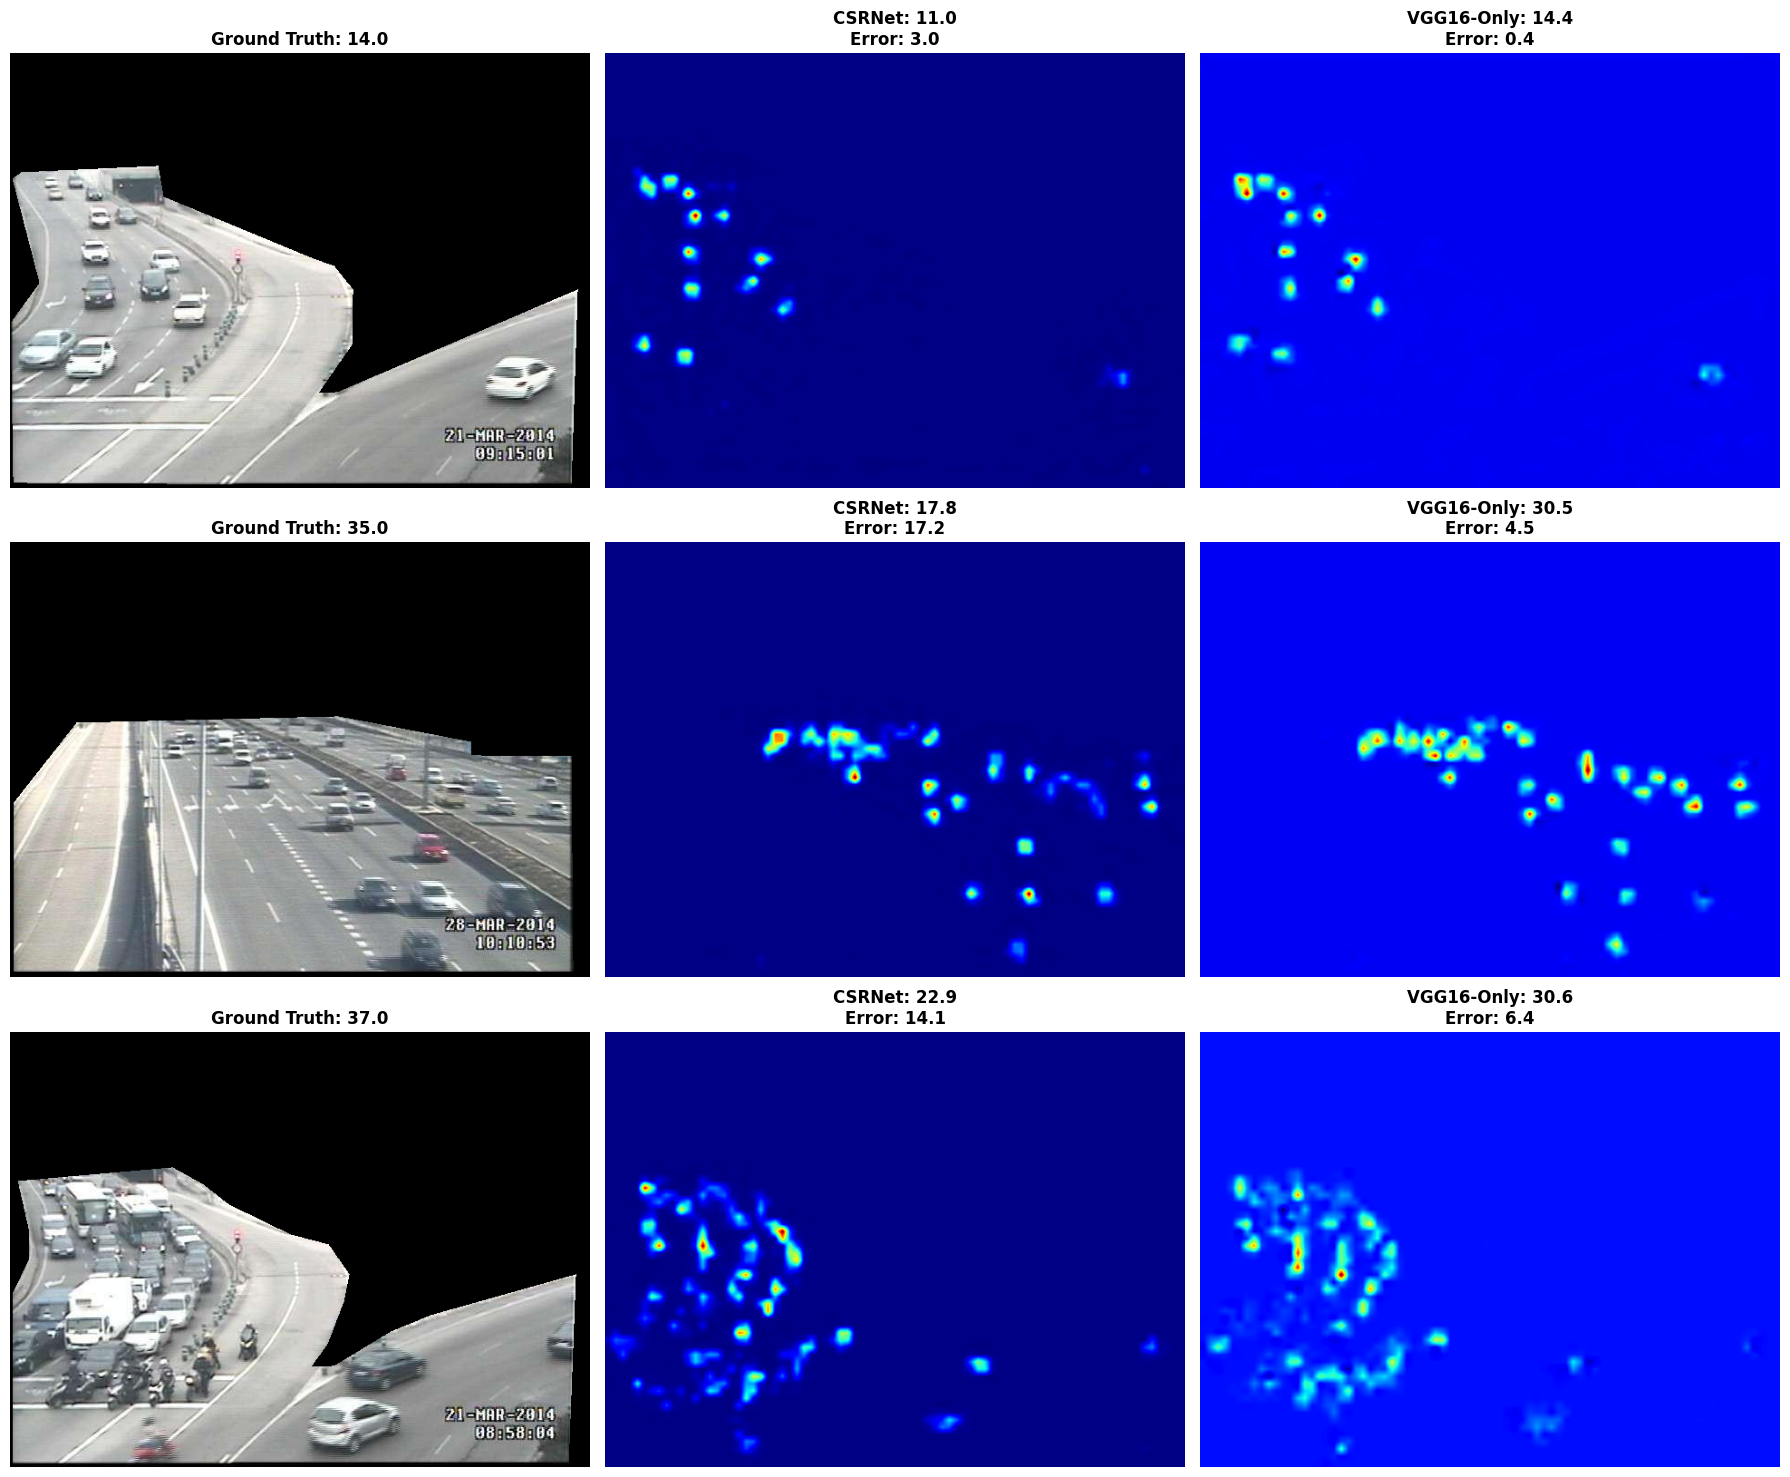


📊 Predictions comparison saved as 'predictions_comparison.png'


: 

In [ ]:
import random

csrnet_model.eval()
vgg16_model.eval()

# Select 3 random test images
indices = random.sample(range(len(test_ds)), 3)

fig, axes = plt.subplots(3, 3, figsize=(18, 15))
# fig.suptitle('Model Predictions Comparison', fontsize=16, fontweight='bold')

with torch.no_grad():
    for row_idx, idx in enumerate(indices):
        img, density = test_ds[idx]
        img_input = img.unsqueeze(0).to(device)
        
        # Get predictions from both models
        csrnet_pred = csrnet_model(img_input)
        vgg16_pred = vgg16_model(img_input)
        
        csrnet_count = csrnet_pred.sum().item() / 100.0
        vgg16_count = vgg16_pred.sum().item() / 100.0
        gt_count = density.sum().item() / 100.0
        
        # Denormalize image
        img_np = img.permute(1, 2, 0).cpu().numpy()
        img_np = img_np * np.array([0.229, 0.224, 0.225]) + np.array([0.485, 0.456, 0.406])
        img_np = np.clip(img_np, 0, 1)
        
        # Original image
        axes[row_idx, 0].imshow(img_np)
        axes[row_idx, 0].set_title(f'Ground Truth: {gt_count:.1f}', 
                                    fontsize=12, fontweight='bold')
        axes[row_idx, 0].axis('off')
        
        # CSRNet prediction
        csrnet_map = csrnet_pred[0, 0].cpu().numpy()
        csrnet_map = cv2.resize(csrnet_map, (img_np.shape[1], img_np.shape[0]))
        axes[row_idx, 1].imshow(csrnet_map, cmap='jet')
        axes[row_idx, 1].set_title(f'CSRNet: {csrnet_count:.1f}\nError: {abs(csrnet_count-gt_count):.1f}', 
                                    fontsize=12, fontweight='bold')
        axes[row_idx, 1].axis('off')
        
        # VGG16-Only prediction
        vgg16_map = vgg16_pred[0, 0].cpu().numpy()
        vgg16_map = cv2.resize(vgg16_map, (img_np.shape[1], img_np.shape[0]))
        axes[row_idx, 2].imshow(vgg16_map, cmap='jet')
        axes[row_idx, 2].set_title(f'VGG16-Only: {vgg16_count:.1f}\nError: {abs(vgg16_count-gt_count):.1f}', 
                                    fontsize=12, fontweight='bold')
        axes[row_idx, 2].axis('off')

plt.tight_layout()
plt.savefig('predictions_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n📊 Predictions comparison saved as 'predictions_comparison.png'")

# Don't use part after this

## Summary Report

In [1]:
print("\n" + "="*80)
print(" " * 20 + "FINAL SUMMARY REPORT")
print("="*80)

print("\n📊 MODEL COMPARISON:\n")
print(f"{'Metric':<25} {'CSRNet':<20} {'VGG16-Only':<20} {'Winner'}")
print("-" * 80)

metrics_comparison = [
    ('MAE', csrnet_eval['mae'], vgg16_eval['mae'], 'lower'),
    ('RMSE', csrnet_eval['rmse'], vgg16_eval['rmse'], 'lower'),
    ('MAPE (%)', csrnet_eval['mape'], vgg16_eval['mape'], 'lower'),
    ('R² Score', csrnet_eval['r2'], vgg16_eval['r2'], 'higher'),
    ('Max Error', csrnet_eval['max_error'], vgg16_eval['max_error'], 'lower'),
    ('Training Time (min)', csrnet_results['total_time']/60, vgg16_results['total_time']/60, 'lower'),
    ('Avg Epoch Time (s)', csrnet_results['avg_epoch_time'], vgg16_results['avg_epoch_time'], 'lower'),
]

csrnet_wins = 0
vgg16_wins = 0

for metric_name, csrnet_val, vgg16_val, criterion in metrics_comparison:
    if criterion == 'lower':
        winner = 'CSRNet ✓' if csrnet_val < vgg16_val else 'VGG16-Only ✓'
        if csrnet_val < vgg16_val:
            csrnet_wins += 1
        else:
            vgg16_wins += 1
    else:
        winner = 'CSRNet ✓' if csrnet_val > vgg16_val else 'VGG16-Only ✓'
        if csrnet_val > vgg16_val:
            csrnet_wins += 1
        else:
            vgg16_wins += 1
    
    print(f"{metric_name:<25} {csrnet_val:<20.4f} {vgg16_val:<20.4f} {winner}")

print("\n" + "="*80)
print(f"\n🏆 OVERALL WINNER: {'CSRNet' if csrnet_wins > vgg16_wins else 'VGG16-Only'}")
print(f"   CSRNet wins: {csrnet_wins}/{len(metrics_comparison)}")
print(f"   VGG16-Only wins: {vgg16_wins}/{len(metrics_comparison)}")
print("\n" + "="*80)

print("\n💡 KEY INSIGHTS:")
print(f"   • CSRNet Final Loss: {csrnet_results['train_losses'][-1]:.4f}")
print(f"   • VGG16-Only Final Loss: {vgg16_results['train_losses'][-1]:.4f}")
print(f"   • Performance Improvement (MAE): {abs(csrnet_eval['mae'] - vgg16_eval['mae']):.2f} vehicles")
print(f"   • Training Time Difference: {abs(csrnet_results['total_time'] - vgg16_results['total_time'])/60:.2f} minutes")
print("\n" + "="*80 + "\n")


                    FINAL SUMMARY REPORT

📊 MODEL COMPARISON:

Metric                    CSRNet               VGG16-Only           Winner
--------------------------------------------------------------------------------


NameError: name 'csrnet_eval' is not defined